# Fashion MNIST
### Context
- Fashion-MNIST is a dataset of Zalando's article images—consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes. Zalando intends Fashion-MNIST to serve as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. It shares the same image size and structure of training and testing splits.

### Goal
- classify grayscale Fashion-MNIST images into 10 classes.

### Import
- first, I import tensorflow as tf for short name, and then check the version of tf and keras


In [3]:
import tensorflow as tf
from tensorflow.keras import layers

from tensorflow import keras
print (f"Tensorflow: {tf.__version__})\nKeras: {keras.__version__}")



Tensorflow: 2.20.0)
Keras: 3.13.2


In [4]:
import matplotlib.pyplot as plt 
import numpy as np
import random

## 1. load data

In [5]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
print(f"Số lượng ảnh training: {X_train.shape[0]}")
print(f"Kích thước mỗi ảnh: {X_train.shape[1]}x{X_train.shape[2]}")
print(f"Nhãn đầu tiên: {y_train[0]}")
X_train[90] #this is how computer see picture, each pixel is a gray scale from 0 to 255

Số lượng ảnh training: 60000
Kích thước mỗi ảnh: 28x28
Nhãn đầu tiên: 9


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   1,
          0,   0,   0, 100, 141,   1,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   0,   2,
          1,   0,   0, 153, 196, 188,  45,   0,   0,   1,   1,   2,   2,
          0,   0],
       [  

In [6]:
class_names = ["Tshirt/top","Trouser","Pullover","Dress","Coat",
                "Sandal","Shirt","Sneaker","Bag","Ankle boot"]
lable = y_train[99]
print (lable)
print (class_names[lable])
# Computer get the 99 picture, and the label is 8, 
# and 9 is Ankle boot in class_name

8
Bag


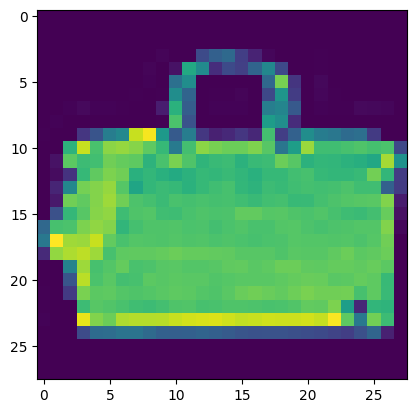

In [7]:
plt.imshow(X_train[99])
#show pic [99] is a bag

- This code below defines a function to randomly display images from your dataset onto a grid. It helps me quickly check what the data looks like.

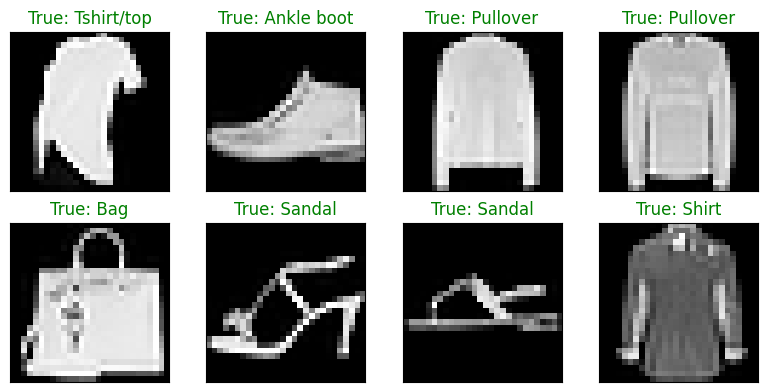

In [8]:
def plot_data(x_data: np.ndarray, y_data: np.ndarray) -> None:
    nrows, ncols = [2 ,4]
    fig, axes = plt.subplots(nrows, ncols, figsize=(8,4))

    len_x = x_data.shape[0]
    for idx in range(nrows*ncols):
        ax = axes[idx // ncols, idx % ncols]

        img_idx = random.randint (0, len_x)

        ax.imshow(x_data[img_idx], cmap = 'gray')
        ax.set(xticks=[], yticks=[]) # just cosmetic, remove number

        true_label_str = f"True: {class_names[y_data[img_idx]]}"
        ax.set_title(true_label_str, color='green',fontsize=12)

    plt.tight_layout()
    plt.show()

plot_data(X_train, y_train)


### 2. Image Pre-Processing
- Reshaping it into the shape the model expects and scaling it, so that all values are in the [0, 1] interval
- Transform from `unit8` it into `float32`
---




vẫn có đầy đủ các sắc thái đậm nhạt, chỉ là cái "thước đo" đã thay đổi thôi:
- Mức cũ: $0 \rightarrow 127 \rightarrow 255$
- Mức mới: $0.0 \rightarrow 0.5 \rightarrow 1.0$

In [9]:
#convert to float 32 and scale image to [0.1] range for the training
X_train = X_train.astype(np.float32) / 255 
X_test = X_test.astype(np.float32) / 255


In [10]:
X_train.dtype,X_train.shape, X_test.shape

(dtype('float32'), (60000, 28, 28), (10000, 28, 28))

At this time, our data just have 3 dimension (sample, height, weight), I need to make the fouth one: channel

In [11]:
X_train = np.expand_dims(X_train, axis=-1)
X_train.shape

(60000, 28, 28, 1)

In [12]:
X_test = np.expand_dims(X_test, axis=-1)
X_test.shape

(10000, 28, 28, 1)

Tiếp theo, thực hiện một kỹ thuật cực kỳ quan trọng trong Machine Learning gọi là One-Hot Encoding.
#### Cấu trúc của y_train_label (One-Hot Vector)
- Thay vì một con số đơn lẻ, mỗi nhãn bây giờ là một hàng có 10 cột (tương ứng 10 lớp). Chỉ có duy nhất một cột có giá trị 1 (đang "hot"), còn lại là 0.

- Ví dụ với tấm ảnh đầu tiên là Ankle boot (số 9):

    - y_train[0]: 9

    - y_train_label[0]: [0, 0, 0, 0, 0, 0, 0, 0, 0, 1] (Số 1 nằm ở vị trí cuối cùng).

Ví dụ với T-shirt (số 0):

- y_train_label: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0] (Số 1 nằm ở vị trí đầu tiên).

In [13]:
class_nums = len(class_names)
print(class_nums)
y_train_label = keras.utils.to_categorical(y_train, class_nums)
y_test_label = keras.utils.to_categorical(y_test, class_nums)

10


In [14]:
y_train[0], y_train_label[0]

(np.uint8(9), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]))

### 3. Network (ANN) Architecture

In [15]:
# This line declares the structure 
# of the input image that the model will receive:
# 28, 28: Height and width (pixels),
# 1: Number of color channels (in this case, grayscale).
input_shape = (28,28,1)

In [16]:
model = keras.models.Sequential([ #Sequential nghĩa là "tuần tự". Dữ liệu sẽ đi vào từ lớp đầu tiên, chạy qua các lớp ở giữa và ra ở lớp cuối cùng theo một đường thẳng, không chạy nhảy lung tung.
    layers.Flatten(input_shape=input_shape)# làm phẳng, Từ một hình vuông 28*# mes 28$, nó biến thành một sợi dây dài chứa 784 con số ($28 \times 28 = 784$)


])

model.summary()

/Users/beam/2026_spring/IoT_Pipline_2026/ML/tf-env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Dense Layer: Also known as the Fully Connected Layer. In this layer, each number from the previous layer (784 numbers from the image) will be connected to all the neurons in this layer.
- 784 số (từ lớp Flatten) ùa vào lớp Dense.

- Mỗi số được nhân với một trọng số (Weight) và cộng thêm một sai số (Bias).

- Kết quả được đẩy qua hàm ReLU.

- Nếu kết quả "có ý nghĩa" (dương), nó sẽ được truyền đến lớp tiếp theo để máy đưa ra quyết định cuối cùng.

#### Add 256:
- Lớp 512 (Lớp đầu): Soi các chi tiết thô, đơn giản như các đường kẻ, góc nhọn, hoặc các đốm sáng tối của điểm ảnh.

- Lớp 256 (Lớp mới thêm): Nó không nhìn vào điểm ảnh nữa, mà nó "nghe" báo cáo từ 512 ông nơ-ron trước đó. Nó sẽ kết hợp các đường kẻ thành các hình khối lớn hơn như: "cổ áo", "gót giày", hay "ống quần".

#### 'softmax' layer:
- Nếu các lớp trước đó (512 và 256 nơ-ron) đóng vai trò phân tích các chi tiết, thì lớp này sẽ tổng hợp tất cả lại để đưa ra câu trả lời cuối cùng.
- Vì bộ dữ liệu của bạn có 10 loại quần áo (T-shirt, Trouser, Bag...), nên lớp cuối cùng bắt buộc phải có 10 nơ-ron.
- Trước khi đi qua Softmax, kết quả của 10 nơ-ron này có thể là bất kỳ con số nào (ví dụ: 10.5, -2.1, 0.3...). Những con số này rất khó để chúng ta hiểu là máy đang tự tin bao nhiêu %.

In [17]:
model = keras.models.Sequential([
    layers.Flatten(input_shape=input_shape),
    layers.Dense(512,activation='relu'),
    layers.Dense(256,activation='relu'),
    layers.Dense(class_nums,activation='softmax')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

![My image](image/image.png)


#### model.compile is the step where establish learning rules
- hàm loss function là để so sánh kết quả máy đã dự đoán, với kết quả y_label

![image](image/image2.png)
- sau đó đưa loss score vào optimizer, để biết sửa cái gì.
- Đây là lúc Optimizer (như Adam hay RMSprop) xuất hiện. Nó nhận cái Loss Score đó và thực hiện một động tác ngược lại (Backpropagation):

    - Nó chạy ngược từ lớp cuối lên lớp đầu.

    - Nó tính toán xem: "Trong số 401,920 tham số ở lớp Dense, cái nào đã làm cho kết quả bị sai?".

    - Sau đó, nó tăng hoặc giảm giá trị của các trọng số (weights) một chút xíu để lần sau Loss Score sẽ nhỏ hơn lần này.

In [18]:
model.compile(optimizer = 'rmsprop',
                loss = 'categorical_crossentropy',
                metrics = ['accuracy'])
                
        
                

#### Let's train the model!
- `model.fit` chính là lúc buổi học bắt đầu.
##### 1. batch_size = 128 (Học theo nhóm)
Thay vì bắt máy tính nhìn từng tấm ảnh một rồi sửa lỗi (rất chậm), hoặc bắt nó nhìn cả 60,000 tấm cùng lúc (quá nặng cho bộ nhớ), chúng ta chia dữ liệu thành từng nhóm nhỏ.

- Ý nghĩa: Máy sẽ bốc ra 128 tấm ảnh ngẫu nhiên để xem xét cùng một lúc.

- Quá trình: Nó tính toán sai số (Loss) trung bình của 128 tấm này, sau đó báo cho Optimizer cập nhật trọng số một lần.

- Lợi ích: Giúp việc tính toán ổn định hơn và tận dụng được sức mạnh xử lý song song của phần cứng (CPU/GPU).

##### 2. epochs = 10 (Số lần đọc hết cuốn sách)
- Một Epoch là một lần mô hình được xem toàn bộ bộ dữ liệu huấn luyện (tất cả 60,000 ảnh).

- Tại sao không phải 1 lần? Vì mạng thần kinh không thể giỏi ngay lập tức. Mỗi lần đọc lại "cuốn sách" dữ liệu, Optimizer lại tinh chỉnh các trọng số thêm một chút để thông minh hơn.

- epochs = 10: Nghĩa là bạn cho máy "ôn đi ôn lại" bộ ảnh này 10 lần.

- Lưu ý: Nếu epoch quá ít, máy sẽ "học chưa tới" (Underfitting). Nếu quá nhiều, máy sẽ "học vẹt" (Overfitting). 10-20 là con số khởi đầu khá đẹp cho bài toán này.

##### validation_split = 0.1 nghĩa là gì?
- Dòng này yêu cầu Keras trích ra 10% dữ liệu ngẫu nhiên từ bộ X_train (6,000 ảnh trong tổng số 60,000 ảnh) để làm dữ liệu xác thực (Validation set). 90% còn lại (54,000 ảnh) vẫn được dùng để huấn luyện bình thường.




In [19]:
epochs = 10
batch_size = 128
history = model.fit(X_train, y_train_label,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7956 - loss: 0.5614 - val_accuracy: 0.8442 - val_loss: 0.4229
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8586 - loss: 0.3815 - val_accuracy: 0.8695 - val_loss: 0.3719
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8761 - loss: 0.3366 - val_accuracy: 0.8695 - val_loss: 0.3729
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8844 - loss: 0.3104 - val_accuracy: 0.8803 - val_loss: 0.3255
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8910 - loss: 0.2890 - val_accuracy: 0.8815 - val_loss: 0.3245
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8971 - loss: 0.2716 - val_accuracy: 0.8817 - val_loss: 0.3271
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9010 - loss: 0.2603 - val_accuracy: 0.8710 - val_loss: 0.3636
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9060 - loss: 0.2478 - val_accuracy: 0.

In [20]:
history_dict = history.history

In [21]:
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [22]:
train_loss, val_loss = history_dict['loss'], history_dict['val_loss']
train_acc, val_acc = history_dict['accuracy'], history_dict['val_accuracy']

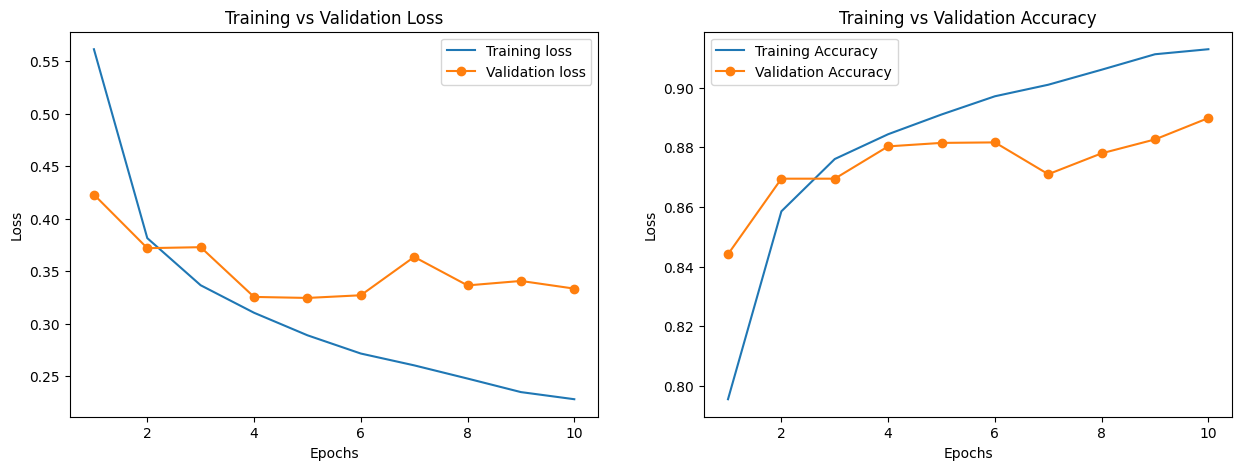

In [23]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize =(15,5))
epoch_runs = [i+1 for i in range(epochs)]

ax1.plot(epoch_runs, train_loss, label='Training loss')
ax1.plot(epoch_runs, val_loss, label='Validation loss', marker='o')
ax1.set(title='Training vs Validation Loss', xlabel='Epochs',ylabel='Loss')
ax1.legend()

ax2.plot(epoch_runs, train_acc, label='Training Accuracy')
ax2.plot(epoch_runs, val_acc, label='Validation Accuracy', marker='o')
ax2.set(title='Training vs Validation Accuracy', xlabel='Epochs',ylabel='Loss')
ax2.legend()

plt.show()


### 4. Model Evaluation

In [24]:
score = model.evaluate(X_test, y_test_label)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - accuracy: 0.8809 - loss: 0.3480


In [25]:
print (f'Test Loss: {score[0]:.4f}')
print (f'Test Accuracy: {score[1]:.4f}')

Test Loss: 0.3480
Test Accuracy: 0.8809


### 5.Prediction

In [26]:
X_sample = X_test[:3]
y_proba = model.predict(X_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [27]:
y_proba

array([[1.3057169e-08, 1.0397229e-07, 5.4776489e-08, 5.8376122e-07,
        7.9671807e-08, 3.9931896e-04, 2.9326370e-06, 2.8120499e-04,
        2.9674407e-08, 9.9931574e-01],
       [3.6413178e-06, 3.7742280e-14, 9.9738449e-01, 2.6915586e-10,
        2.4551020e-03, 3.2324967e-13, 1.5675637e-04, 1.3444406e-12,
        2.2707305e-13, 2.1978567e-12],
       [1.2437778e-18, 1.0000000e+00, 1.3394206e-21, 1.4745367e-15,
        1.5341609e-20, 2.1105387e-25, 1.1272536e-17, 1.0087221e-26,
        7.6284370e-23, 2.7777514e-28]], dtype=float32)

In [28]:
y_proba.round(3)

array([[0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.999],
       [0.   , 0.   , 0.997, 0.   , 0.002, 0.   , 0.   , 0.   , 0.   ,
        0.   ],
       [0.   , 1.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   ]], dtype=float32)

In [33]:
predictions = np.argmax(y_proba, axis=1)
# for pred in predictions:

In [34]:
[class_names[pred]for pred in predictions]

['Ankle boot', 'Pullover', 'Trouser']

In [35]:
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
